In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

In [2]:

import requests

url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

response = requests.get(url)
response.raise_for_status()

with open("/content/online_retail_ii.zip", "wb") as f:
    f.write(response.content)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:

import zipfile
import os

zip_path = "/content/online_retail_ii.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/retail_data")

print("Files extracted:")
print(os.listdir("/content/retail_data"))

Files extracted:
['online_retail_II.xlsx']


In [4]:

import pandas as pd
import os

file_path = "/content/retail_data/online_retail_II.xlsx"

print("File exists:", os.path.exists(file_path))

File exists: True


In [5]:
import pandas as pd

file_path = "/content/retail_data/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [6]:
df1 = pd.read_excel(
    file_path,
    sheet_name='Year 2009-2010'
)

df2 = pd.read_excel(
    file_path,
    sheet_name='Year 2010-2011'
)

print("First sheet:", df1.shape)
print("Second sheet:", df2.shape)


First sheet: (525461, 8)
Second sheet: (541910, 8)


In [7]:
df = pd.concat([df1, df2], ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [11]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [12]:
# Remove rows where product description is missing
df = df.dropna(subset=['Description'])

# Remove cancelled invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Keep only positive quantities
df = df[df['Quantity'] > 0]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (1042727, 8)


In [13]:
df[['Invoice', 'Description', 'Quantity']].head(10)

,Invoice,Description,Quantity
0,489434,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12
1,489434,PINK CHERRY LIGHTS,12
2,489434,WHITE CHERRY LIGHTS,12
3,489434,"RECORD FRAME 7"" SINGLE SIZE",48
4,489434,STRAWBERRY CERAMIC TRINKET BOX,24
5,489434,PINK DOUGHNUT TRINKET POT,24
6,489434,SAVE THE PLANET MUG,24
7,489434,FANCY FONT HOME SWEET HOME DOORMAT,10
8,489435,CAT BOWL,12
9,489435,"DOG BOWL , CHASING BALL DESIGN",12


In [14]:
basket_data = df[['Invoice', 'Description']].copy()

print(basket_data.shape)
basket_data.head(10)

(1042727, 2)


,Invoice,Description
0,489434,15CM CHRISTMAS GLASS BALL 20 LIGHTS
1,489434,PINK CHERRY LIGHTS
2,489434,WHITE CHERRY LIGHTS
3,489434,"RECORD FRAME 7"" SINGLE SIZE"
4,489434,STRAWBERRY CERAMIC TRINKET BOX
5,489434,PINK DOUGHNUT TRINKET POT
6,489434,SAVE THE PLANET MUG
7,489434,FANCY FONT HOME SWEET HOME DOORMAT
8,489435,CAT BOWL
9,489435,"DOG BOWL , CHASING BALL DESIGN"


In [15]:
basket_data = basket_data.drop_duplicates()

print("After removing duplicates:", basket_data.shape)

After removing duplicates: (997007, 2)


In [16]:
transactions = basket_data.groupby('Invoice')['Description'].apply(list)

print("Number of transactions:", len(transactions))

Number of transactions: 40301


In [17]:
transactions.head()

,Description
Invoice,
489434,"[15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK CHE..."
489435,"[CAT BOWL , DOG BOWL , CHASING BALL DESIGN, HE..."
489436,"[DOOR MAT BLACK FLOCK , LOVE BUILDING BLOCK WO..."
489437,"[CHRISTMAS CRAFT HEART DECORATIONS, CHRISTMAS ..."
489438,"[DINOSAURS WRITING SET , SET OF MEADOW FLOWE..."


In [18]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for products in transactions:
    # Remove duplicates and sort products
    products = sorted(set(products))

    # Create combinations of 2 products
    for pair in combinations(products, 2):
        pair_counter[pair] += 1

print("Total unique product pairs:", len(pair_counter))

Total unique product pairs: 5906472


In [19]:
pair_df = pd.DataFrame(
    pair_counter.items(),
    columns=['Product Pair', 'Frequency']
)

pair_df.head(10)

,Product Pair,Frequency
0,"( WHITE CHERRY LIGHTS, 15CM CHRISTMAS GLASS BA...",12
1,"( WHITE CHERRY LIGHTS, FANCY FONT HOME SWEET H...",34
2,"( WHITE CHERRY LIGHTS, PINK CHERRY LIGHTS)",117
3,"( WHITE CHERRY LIGHTS, PINK DOUGHNUT TRINKET P...",20
4,"( WHITE CHERRY LIGHTS, RECORD FRAME 7"" SINGLE ...",5
5,"( WHITE CHERRY LIGHTS, SAVE THE PLANET MUG)",26
6,"( WHITE CHERRY LIGHTS, STRAWBERRY CERAMIC TRIN...",45
7,"(15CM CHRISTMAS GLASS BALL 20 LIGHTS, FANCY FO...",8
8,"(15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK CHE...",10
9,"(15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK DOU...",31


In [20]:
pair_df = pair_df.sort_values(
    by='Frequency',
    ascending=False
).reset_index(drop=True)

pair_df.head(10)

,Product Pair,Frequency
0,"(RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI...",1240
1,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F...",1114
2,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",1096
3,"(STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CE...",1052
4,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",1024
5,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAG...",1008
6,"(HEART OF WICKER LARGE, HEART OF WICKER SMALL)",1005
7,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",966
8,"(JUMBO BAG RED RETROSPOT, JUMBO BAG STRAWBERRY)",926
9,"(60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK ...",926


In [21]:
combinations(products, 2)

In [22]:
top_10_pairs = pair_df.head(10).copy()

top_10_pairs

,Product Pair,Frequency
0,"(RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI...",1240
1,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F...",1114
2,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",1096
3,"(STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CE...",1052
4,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",1024
5,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAG...",1008
6,"(HEART OF WICKER LARGE, HEART OF WICKER SMALL)",1005
7,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",966
8,"(JUMBO BAG RED RETROSPOT, JUMBO BAG STRAWBERRY)",926
9,"(60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK ...",926


In [23]:
top_10_pairs[['Product 1', 'Product 2']] = pd.DataFrame(
    top_10_pairs['Product Pair'].tolist(),
    index=top_10_pairs.index
)

top_10_pairs

,Product Pair,Frequency,Product 1,Product 2
0,"(RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI...",1240,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER
1,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F...",1114,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH
2,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",1096,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI
3,"(STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CE...",1052,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX
4,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",1024,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER
5,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAG...",1008,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY
6,"(HEART OF WICKER LARGE, HEART OF WICKER SMALL)",1005,HEART OF WICKER LARGE,HEART OF WICKER SMALL
7,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",966,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT
8,"(JUMBO BAG RED RETROSPOT, JUMBO BAG STRAWBERRY)",926,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY
9,"(60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK ...",926,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES


In [24]:
top_10_pairs = top_10_pairs[
    ['Product 1', 'Product 2', 'Frequency']
]

top_10_pairs

,Product 1,Product 2,Frequency
0,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,1240
1,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,1114
2,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,1096
3,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,1052
4,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,1024
5,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY,1008
6,HEART OF WICKER LARGE,HEART OF WICKER SMALL,1005
7,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,966
8,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,926
9,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,926


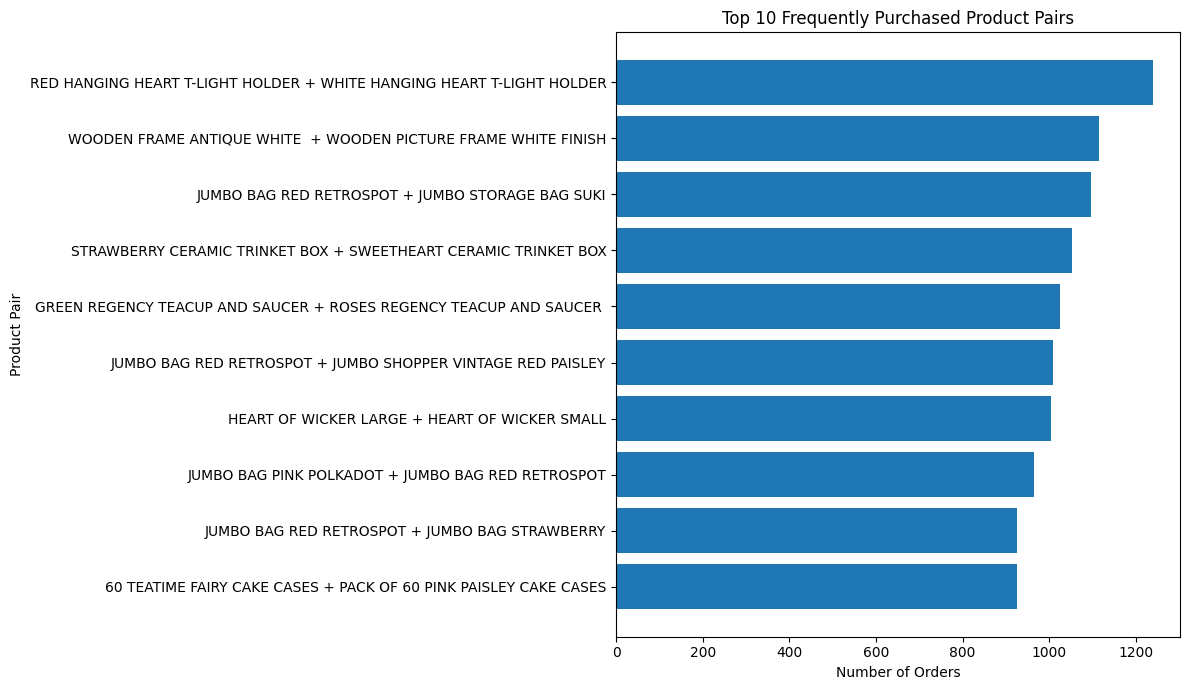

In [25]:
plt.figure(figsize=(12, 7))

labels = (
    top_10_pairs['Product 1'] +
    ' + ' +
    top_10_pairs['Product 2']
)

plt.barh(labels, top_10_pairs['Frequency'])

plt.xlabel('Number of Orders')
plt.ylabel('Product Pair')
plt.title('Top 10 Frequently Purchased Product Pairs')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [26]:
product_counter = Counter()

for products in transactions:
    for product in set(products):
        product_counter[product] += 1

print("Total unique products:", len(product_counter))

Total unique products: 5469


In [27]:
pair_df['Product 1 Count'] = pair_df['Product 1'].map(product_counter)
pair_df['Product 2 Count'] = pair_df['Product 2'].map(product_counter)

KeyError: 'Product 1'

In [28]:
total_transactions = len(transactions)

print("Total transactions:", total_transactions)

Total transactions: 40301


In [29]:
pair_df['Support'] = (
    pair_df['Frequency'] / total_transactions
)

In [30]:
pair_df[['Product 1', 'Product 2', 'Frequency', 'Support']].head(10)

KeyError: "['Product 1', 'Product 2'] not in index"

In [31]:
pair_df[['Product 1', 'Product 2']] = pd.DataFrame(
    pair_df['Product Pair'].tolist(),
    index=pair_df.index
)

pair_df.head()

,Product Pair,Frequency,Support,Product 1,Product 2
0,"(RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI...",1240,0.030768,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER
1,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F...",1114,0.027642,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH
2,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",1096,0.027195,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI
3,"(STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CE...",1052,0.026104,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX
4,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",1024,0.025409,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER


In [32]:
print(pair_df.columns.tolist())

['Product Pair', 'Frequency', 'Support', 'Product 1', 'Product 2']


In [33]:
pair_df['Product 1 Count'] = pair_df['Product 1'].map(product_counter)
pair_df['Product 2 Count'] = pair_df['Product 2'].map(product_counter)

In [35]:
total_transactions = len(transactions)

pair_df['Support'] = (
    pair_df['Frequency'] / total_transactions
)

In [36]:
pair_df['Confidence 1→2'] = (
    pair_df['Frequency'] / pair_df['Product 1 Count']
)

pair_df['Confidence 2→1'] = (
    pair_df['Frequency'] / pair_df['Product 2 Count']
)

In [37]:
pair_df[
    [
        'Product 1',
        'Product 2',
        'Frequency',
        'Support',
        'Confidence 1→2',
        'Confidence 2→1'
    ]
].head(10)

,Product 1,Product 2,Frequency,Support,Confidence 1→2,Confidence 2→1
0,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,1240,0.030768,0.704545,0.227106
1,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,1114,0.027642,0.541039,0.555334
2,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,1096,0.027195,0.334861,0.470386
3,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,1052,0.026104,0.455411,0.709852
4,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,1024,0.025409,0.762472,0.725726
5,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY,1008,0.025012,0.307974,0.459644
6,HEART OF WICKER LARGE,HEART OF WICKER SMALL,1005,0.024937,0.513541,0.466357
7,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,966,0.023970,0.669439,0.295142
8,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,926,0.022977,0.282921,0.498385
9,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,926,0.022977,0.435355,0.464626


In [38]:
recommendations = pair_df.sort_values(
    by='Confidence 1→2',
    ascending=False
).reset_index(drop=True)

recommendations.head(10)

,Product Pair,Frequency,Support,Product 1,Product 2,Product 1 Count,Product 2 Count,Confidence 1→2,Confidence 2→1
0,"(DR WHO TOP TRUMPS GAME, VINTAGE SNAP CARDS)",1,0.000025,DR WHO TOP TRUMPS GAME,VINTAGE SNAP CARDS,1,1888,1.0,0.000530
1,"(DR WHO TOP TRUMPS GAME, VINTAGE UNION JACK AP...",1,0.000025,DR WHO TOP TRUMPS GAME,VINTAGE UNION JACK APRON,1,334,1.0,0.002994
2,"(DR WHO TOP TRUMPS GAME, VIPPASSPORT COVER )",1,0.000025,DR WHO TOP TRUMPS GAME,VIPPASSPORT COVER,1,111,1.0,0.009009
3,"(DR WHO TOP TRUMPS GAME, WATERMELON BATH SPONGE)",1,0.000025,DR WHO TOP TRUMPS GAME,WATERMELON BATH SPONGE,1,215,1.0,0.004651
4,"(DR WHO TOP TRUMPS GAME, SWEETHEART KEY CABINET)",1,0.000025,DR WHO TOP TRUMPS GAME,SWEETHEART KEY CABINET,1,393,1.0,0.002545
5,"(DR WHO TOP TRUMPS GAME, SWISS CHALET TREE DEC...",1,0.000025,DR WHO TOP TRUMPS GAME,SWISS CHALET TREE DECORATION,1,189,1.0,0.005291
6,"(DR WHO TOP TRUMPS GAME, SWISS ROLL TOWEL, CHO...",1,0.000025,DR WHO TOP TRUMPS GAME,"SWISS ROLL TOWEL, CHOCOLATE SPOTS",1,214,1.0,0.004673
7,"(DR WHO TOP TRUMPS GAME, TEA BAG PLATE RED SPO...",1,0.000025,DR WHO TOP TRUMPS GAME,TEA BAG PLATE RED SPOTTY,1,465,1.0,0.002151
8,"(DR WHO TOP TRUMPS GAME, TEA COSY BLUE STRIPE)",1,0.000025,DR WHO TOP TRUMPS GAME,TEA COSY BLUE STRIPE,1,214,1.0,0.004673
9,"(DR WHO TOP TRUMPS GAME, TEA CUP AND SAUCER RE...",1,0.000025,DR WHO TOP TRUMPS GAME,TEA CUP AND SAUCER RETRO SPOT,1,137,1.0,0.007299


In [39]:
recommendations = recommendations[
    [
        'Product 1',
        'Product 2',
        'Frequency',
        'Support',
        'Confidence 1→2',
        'Confidence 2→1'
    ]
].head(10)

recommendations

,Product 1,Product 2,Frequency,Support,Confidence 1→2,Confidence 2→1
0,DR WHO TOP TRUMPS GAME,VINTAGE SNAP CARDS,1,0.000025,1.0,0.000530
1,DR WHO TOP TRUMPS GAME,VINTAGE UNION JACK APRON,1,0.000025,1.0,0.002994
2,DR WHO TOP TRUMPS GAME,VIPPASSPORT COVER,1,0.000025,1.0,0.009009
3,DR WHO TOP TRUMPS GAME,WATERMELON BATH SPONGE,1,0.000025,1.0,0.004651
4,DR WHO TOP TRUMPS GAME,SWEETHEART KEY CABINET,1,0.000025,1.0,0.002545
5,DR WHO TOP TRUMPS GAME,SWISS CHALET TREE DECORATION,1,0.000025,1.0,0.005291
6,DR WHO TOP TRUMPS GAME,"SWISS ROLL TOWEL, CHOCOLATE SPOTS",1,0.000025,1.0,0.004673
7,DR WHO TOP TRUMPS GAME,TEA BAG PLATE RED SPOTTY,1,0.000025,1.0,0.002151
8,DR WHO TOP TRUMPS GAME,TEA COSY BLUE STRIPE,1,0.000025,1.0,0.004673
9,DR WHO TOP TRUMPS GAME,TEA CUP AND SAUCER RETRO SPOT,1,0.000025,1.0,0.007299


In [40]:
recommendations['Confidence 1→2 (%)'] = (
    recommendations['Confidence 1→2'] * 100
).round(2)

recommendations['Confidence 2→1 (%)'] = (
    recommendations['Confidence 2→1'] * 100
).round(2)

recommendations

,Product 1,Product 2,Frequency,Support,Confidence 1→2,Confidence 2→1,Confidence 1→2 (%),Confidence 2→1 (%)
0,DR WHO TOP TRUMPS GAME,VINTAGE SNAP CARDS,1,0.000025,1.0,0.000530,100.0,0.05
1,DR WHO TOP TRUMPS GAME,VINTAGE UNION JACK APRON,1,0.000025,1.0,0.002994,100.0,0.30
2,DR WHO TOP TRUMPS GAME,VIPPASSPORT COVER,1,0.000025,1.0,0.009009,100.0,0.90
3,DR WHO TOP TRUMPS GAME,WATERMELON BATH SPONGE,1,0.000025,1.0,0.004651,100.0,0.47
4,DR WHO TOP TRUMPS GAME,SWEETHEART KEY CABINET,1,0.000025,1.0,0.002545,100.0,0.25
5,DR WHO TOP TRUMPS GAME,SWISS CHALET TREE DECORATION,1,0.000025,1.0,0.005291,100.0,0.53
6,DR WHO TOP TRUMPS GAME,"SWISS ROLL TOWEL, CHOCOLATE SPOTS",1,0.000025,1.0,0.004673,100.0,0.47
7,DR WHO TOP TRUMPS GAME,TEA BAG PLATE RED SPOTTY,1,0.000025,1.0,0.002151,100.0,0.22
8,DR WHO TOP TRUMPS GAME,TEA COSY BLUE STRIPE,1,0.000025,1.0,0.004673,100.0,0.47
9,DR WHO TOP TRUMPS GAME,TEA CUP AND SAUCER RETRO SPOT,1,0.000025,1.0,0.007299,100.0,0.73


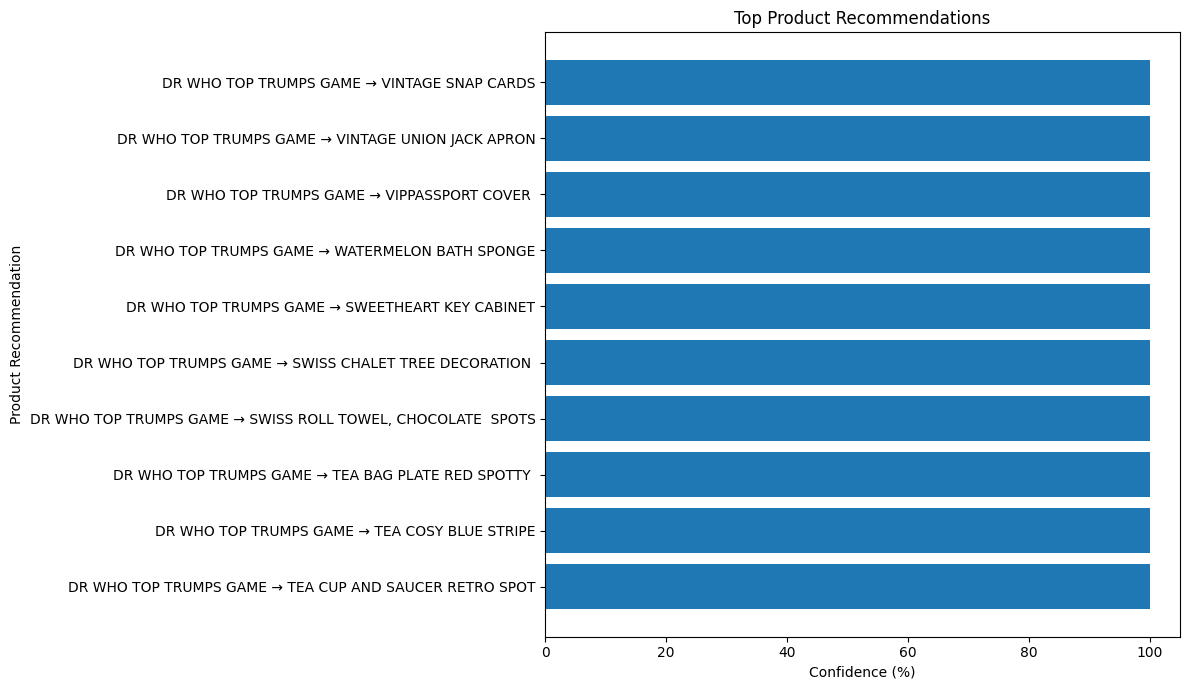

In [41]:
plt.figure(figsize=(12, 7))

labels = (
    recommendations['Product 1'] +
    ' → ' +
    recommendations['Product 2']
)

plt.barh(
    labels,
    recommendations['Confidence 1→2 (%)']
)

plt.xlabel('Confidence (%)')
plt.ylabel('Product Recommendation')
plt.title('Top Product Recommendations')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [42]:
top_10_pairs.to_csv(
    'top_10_product_pairs.csv',
    index=False
)

recommendations.to_csv(
    'product_recommendations.csv',
    index=False
)

print("Files saved successfully!")

Files saved successfully!
